In [76]:
# low = lower range for variables, high = higher range for variables
def genesis(size,var, high , low):
   pop_size = (size,var)
   new_pop = np.random.uniform(low=low,high=high,size=pop_size)
   return new_pop

In [77]:
def fitness(p):
# Evaluating fitness Interference function "double fit (doublep[])".
   fitness=np.zeros((len(p),1))
   for i in range(len(p)):
       x,y,z = p[i][0] , p[i][1] , p[i][2]
        # Define your fitness function here
       fitness[i,0] = 2*x*z*np.exp(-x) - 2*y**3 + y**2 - 3*z**3
   return fitness

In [78]:
def selection(pop, fitness, num_parents):
   parents = np.empty((num_parents, pop.shape[1]))
   for parent_num in range(num_parents):
      max_fitness_idx = np.where(fitness == np.max(fitness))
      max_fitness_idx = max_fitness_idx[0][0]
      parents[parent_num, :] = pop[max_fitness_idx, :]
      fitness[max_fitness_idx] = -99999999999
   return parents

In [79]:
def crossover(parents, offspring_size):
   offspring = np.empty(offspring_size)
   crossover_point = np.uint8(offspring_size[1]/2)
   for k in range(offspring_size[0]):
      parent1_idx = k%parents.shape[0]
      parent2_idx = (k+1)%parents.shape[0]
      offspring[k, 0:crossover_point] = parents[parent1_idx,     0:crossover_point]
      offspring[k, crossover_point:] = parents[parent2_idx, crossover_point:]
   return offspring

In [80]:
def mutation(offspring_crossover):
   for idx in range(offspring_crossover.shape[0]):
      random_value = np.random.uniform(-10, 10, 1)
# 10 percent change maximum keeping 90 percent mutation rate 
      i= randint(0, 2)
      offspring_crossover[idx, i] = offspring_crossover[idx, i] + random_value 
   return offspring_crossover

In [81]:
import numpy as np
from random import randint


num_var = 3
sizeof_pop= 100
upper_limit = 100
lower_limit = -100
num_parents = 2

population = genesis(sizeof_pop , num_var, upper_limit ,lower_limit)
print(population)
Scores=[]
num_generations = 20
for generation in range(num_generations):
   print("\n\nGeneration : ", generation)
   fitness_score = fitness(population)
   parents = selection(population, fitness_score, num_parents)
   print("Best Parents \n",parents)
   offspring_crossover = crossover(parents, offspring_size=(2*num_parents, num_var))
   offspring_mutation = mutation(offspring_crossover)
   print("Mutated OffSprings\n",offspring_mutation)
   population[0:parents.shape[0], :] = parents
   population[parents.shape[0]:6, :] = offspring_mutation
   Scores.append(np.max(fitness_score))
   print("Best result : ", np.max(fitness_score))

[[-9.45089691e+01  9.43139832e+01 -8.12671536e+01]
 [-1.29209008e+01  2.80918347e+01 -1.95104130e+01]
 [ 6.94205955e+01  9.41975647e+01 -5.50509452e+01]
 [ 3.59750441e+01 -1.07129652e+01 -4.98753287e+01]
 [-8.06672006e+01 -3.96258672e+01 -8.71440722e+01]
 [ 8.66674041e+01  2.82991112e+01  5.39195938e+01]
 [ 2.54653156e+01  1.48269317e+01  8.08715031e+01]
 [-6.56103896e+01  6.36385802e+01  5.53949513e+01]
 [ 1.66773750e+01 -4.18402516e+01 -9.07358775e+01]
 [ 9.71205672e+01 -9.53525984e+01 -5.07342410e+01]
 [ 3.14039091e+01 -3.29293152e+01 -2.44234442e+01]
 [-8.64731967e+01  5.07205207e+01  3.01584550e+01]
 [-2.68706765e+01 -7.05351561e+01 -8.83460677e+01]
 [-2.50883464e+01  4.18429614e+01  1.40602221e+01]
 [ 8.70772986e+01 -2.44587409e+01  9.09289768e+01]
 [ 6.11304605e+01 -2.62235981e+01  7.45673199e+01]
 [ 2.82142460e+01 -2.92899883e+01  6.51620763e+00]
 [-2.37886271e+00 -2.14907352e+01 -5.78882906e+01]
 [-8.40509954e+01 -9.54595173e+01 -2.73438498e+01]
 [-2.29749486e+01 -7.55548272e+

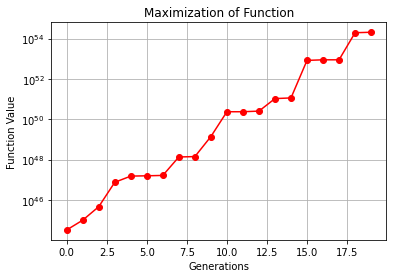

In [82]:
import matplotlib.pyplot as plt
Evaluations = Scores
plt.plot(Evaluations,'o-',color='red')
plt.yscale('log')
plt.xlabel('Generations')
plt.ylabel('Function Value')
plt.title("Maximization of Function")
plt.grid(True)
plt.show()